# Employee Retention Logistic Regression Exercise

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from google.colab import files

uploaded = files.upload()


Saving HR_comma_sep.csv to HR_comma_sep.csv


In [3]:
df = pd.read_csv("HR_comma_sep.csv")

df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
df.groupby('left')[[
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company',
    'Work_accident',
    'promotion_last_5years'
]].mean()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


<Axes: xlabel='salary'>

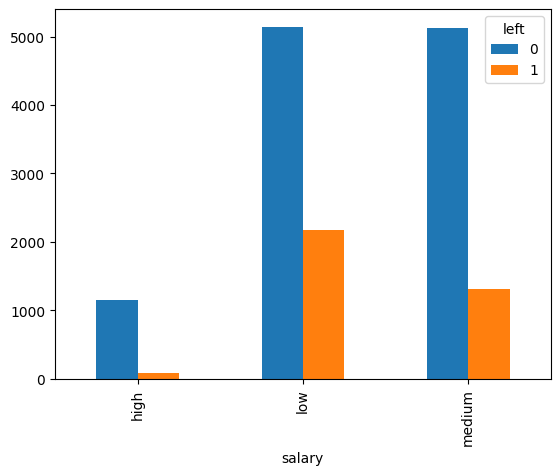

In [6]:
pd.crosstab(df.salary, df.left).plot(kind='bar')


Text(0.5, 1.0, 'Salary vs Employee Retention')

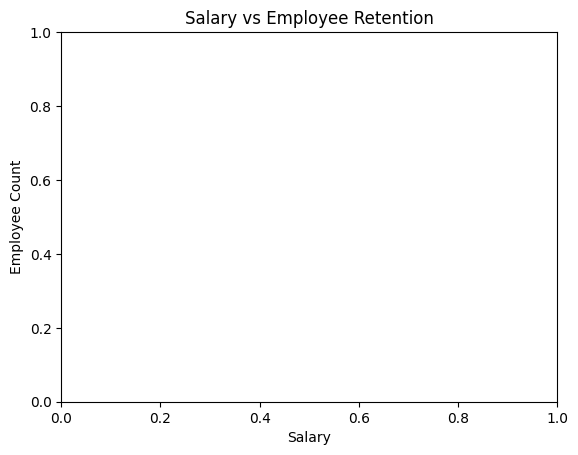

In [7]:
plt.xlabel("Salary")

plt.ylabel("Employee Count")

plt.title("Salary vs Employee Retention")


<Axes: xlabel='Department'>

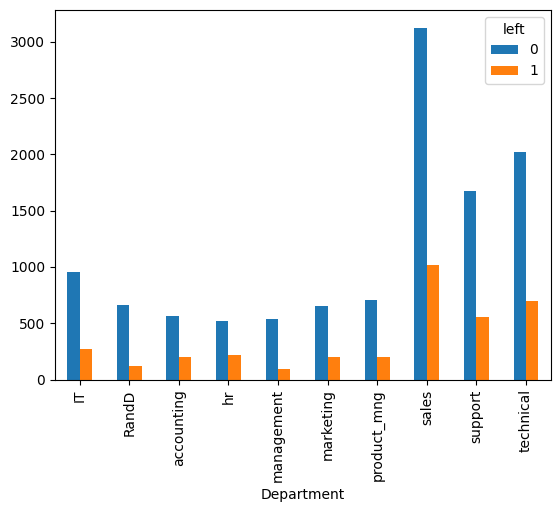

In [8]:
pd.crosstab(df.Department, df.left).plot(kind='bar')


Text(0.5, 1.0, 'Department vs Employee Retention')

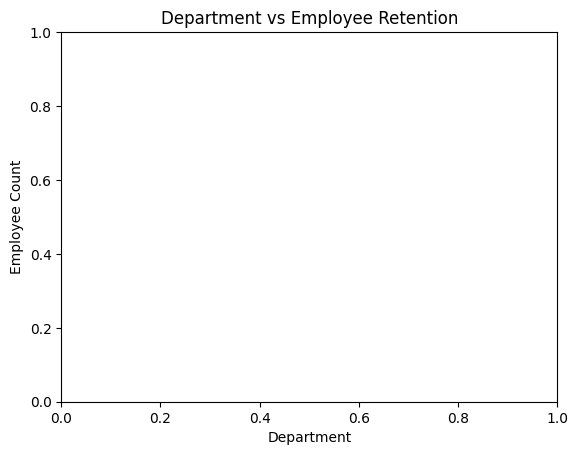

In [9]:
plt.xlabel("Department")

plt.ylabel("Employee Count")

plt.title("Department vs Employee Retention")


In [10]:
subdf = df[[
    'satisfaction_level',
    'average_montly_hours',
    'promotion_last_5years',
    'salary'
]]

subdf.head()


,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [11]:
salary_dummies = pd.get_dummies(
    subdf.salary,
    prefix="salary"
)


In [12]:
df_with_dummies = pd.concat(
    [subdf, salary_dummies],
    axis='columns'
)

df_with_dummies.head()


,satisfaction_level,average_montly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,False,True,False
1,0.80,262,0,medium,False,False,True
2,0.11,272,0,medium,False,False,True
3,0.72,223,0,low,False,True,False
4,0.37,159,0,low,False,True,False


In [13]:
df_with_dummies.drop(
    'salary',
    axis='columns',
    inplace=True
)

df_with_dummies.head()


,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [14]:
df_with_dummies.drop(
    'salary_medium',
    axis='columns',
    inplace=True
)

df_with_dummies.head()


,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low
0,0.38,157,0,False,True
1,0.80,262,0,False,False
2,0.11,272,0,False,False
3,0.72,223,0,False,True
4,0.37,159,0,False,True


In [15]:
X = df_with_dummies

X.head()


,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low
0,0.38,157,0,False,True
1,0.80,262,0,False,False
2,0.11,272,0,False,False
3,0.72,223,0,False,True
4,0.37,159,0,False,True


In [16]:
y = df.left


In [17]:
from sklearn.model_selection import train_test_split


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1
)


In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()


In [20]:
model.fit(X_train, y_train)


LogisticRegression()

In [21]:
model.predict(X_test)


array([0, 0, 0, ..., 0, 1, 0])

In [22]:
model.score(X_test, y_test)


0.7766666666666666